# Telco Customer Churn — Exploratory Data Analysis (EDA)

## Objective

The goal of this notebook is to explore the cleaned dataset to better understand:

- distributions of key variables
- customer characteristics
- relationships between variables
- potential patterns related to churn

This step helps build intuition before performing business, financial, and predictive analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Load Cleaned Dataset

In [2]:
df = pd.read_csv("../data/telco_churn_cleaned.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag,TenureGroup,MonthlyChargesGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-12 months,Low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,0,25-48 months,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-12 months,Medium
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,25-48 months,Medium
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-12 months,High


## Dataset Overview

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (7032, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customerID           7032 non-null   object 
 1   gender               7032 non-null   object 
 2   SeniorCitizen        7032 non-null   int64  
 3   Partner              7032 non-null   object 
 4   Dependents           7032 non-null   object 
 5   tenure               7032 non-null   int64  
 6   PhoneService         7032 non-null   object 
 7   MultipleLines        7032 non-null   object 
 8   InternetService      7032 non-null   object 
 9   OnlineSecurity       7032 non-null   object 
 10  OnlineBackup         7032 non-null   object 
 11  DeviceProtection     7032 non-null   object 
 12  TechSupport          7032 non-null   object 
 13  StreamingTV          7032 non-null   object 
 14  StreamingMovies      7032 non-null   object 
 15  Contract            

## Numeric Variables Distribution

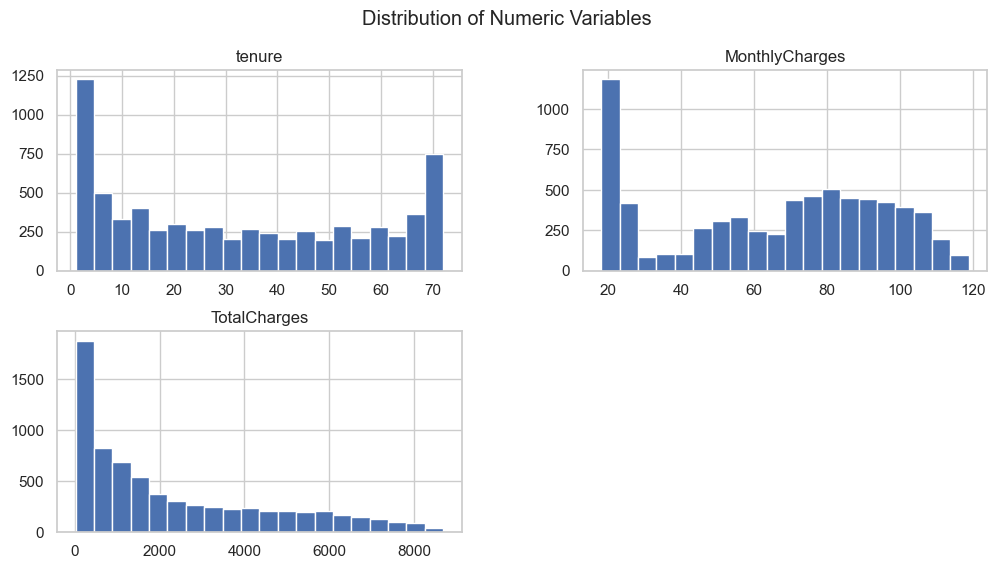

In [4]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

df[numeric_cols].hist(bins=20, figsize=(12, 6))
plt.suptitle("Distribution of Numeric Variables")
plt.show()

These distributions help identify skewness, spread, and potential outliers in the data.

## Tenure Distribution

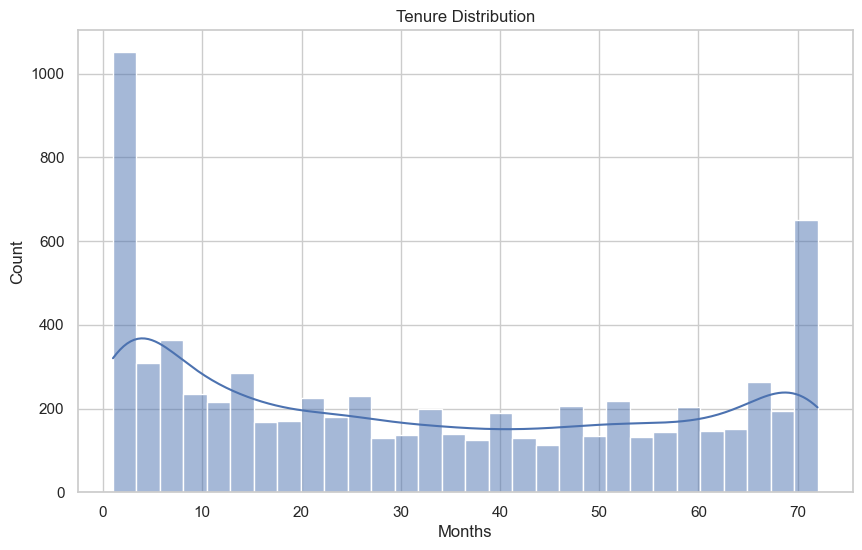

In [5]:
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Tenure Distribution")
plt.xlabel("Months")
plt.ylabel("Count")
plt.show()

We observe how long customers typically stay with the company and whether there is concentration in early or late tenure.

## Monthly Charges Distribution

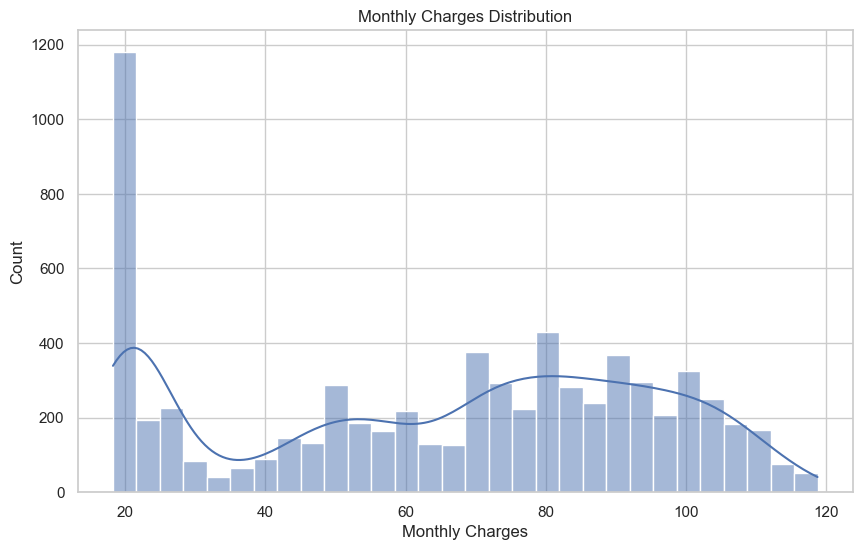

In [6]:
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.show()

This helps identify pricing clusters and whether customers are concentrated in certain price ranges.

This helps identify pricing clusters and whether customers are concentrated in certain price ranges.

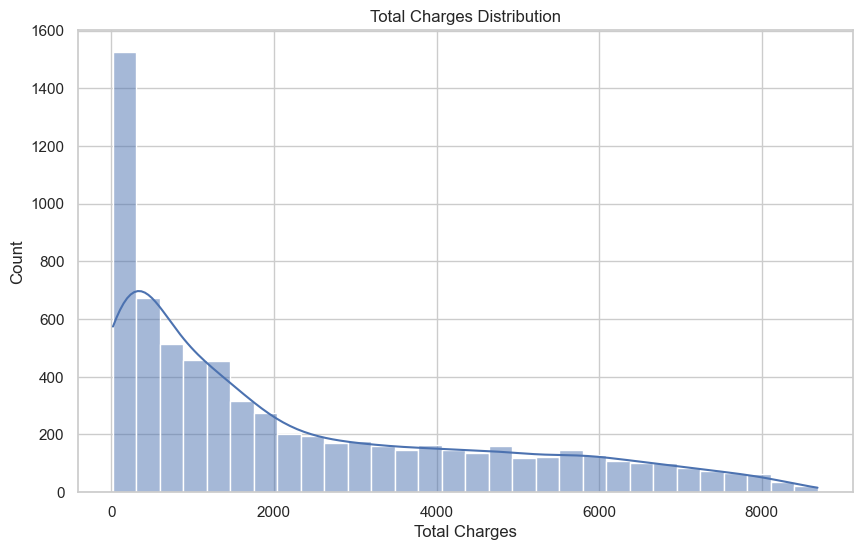

In [7]:
sns.histplot(df["TotalCharges"], bins=30, kde=True)
plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Count")
plt.show()

Total charges reflect accumulated revenue per customer and are influenced by both tenure and monthly charges.

## Categorical Variables Overview

In [8]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


customerID
customerID
7590-VHVEG    1
0265-PSUAE    1
2956-GGUCQ    1
6008-NAIXK    1
5956-YHHRX    1
             ..
7874-ECPQJ    1
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
3186-AJIEK    1
Name: count, Length: 7032, dtype: int64

gender
gender
Male      3549
Female    3483
Name: count, dtype: int64

Partner
Partner
No     3639
Yes    3393
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2099
Name: count, dtype: int64

PhoneService
PhoneService
Yes    6352
No      680
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3087
Yes                    2425


This provides an overview of all categories and their frequency.

## Churn Distribution

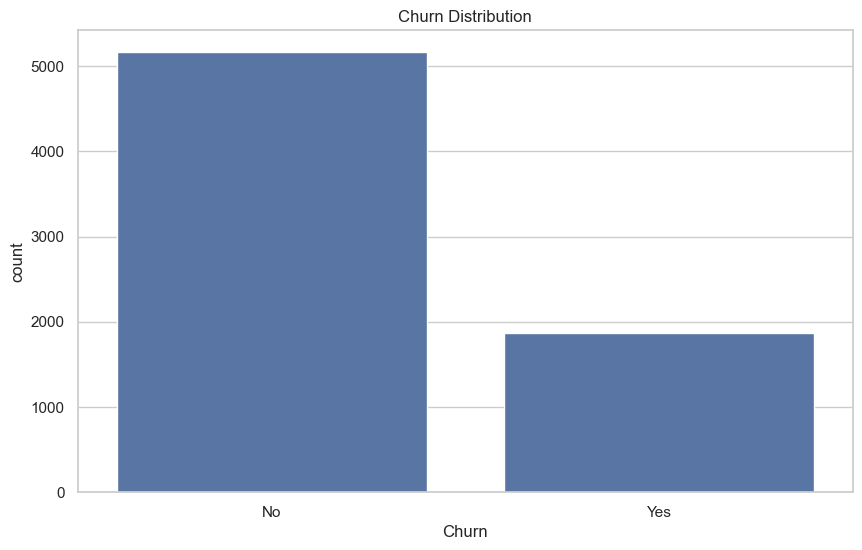

In [9]:
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.show()

We confirm the proportion of churned vs retained customers.

## Churn by Gender

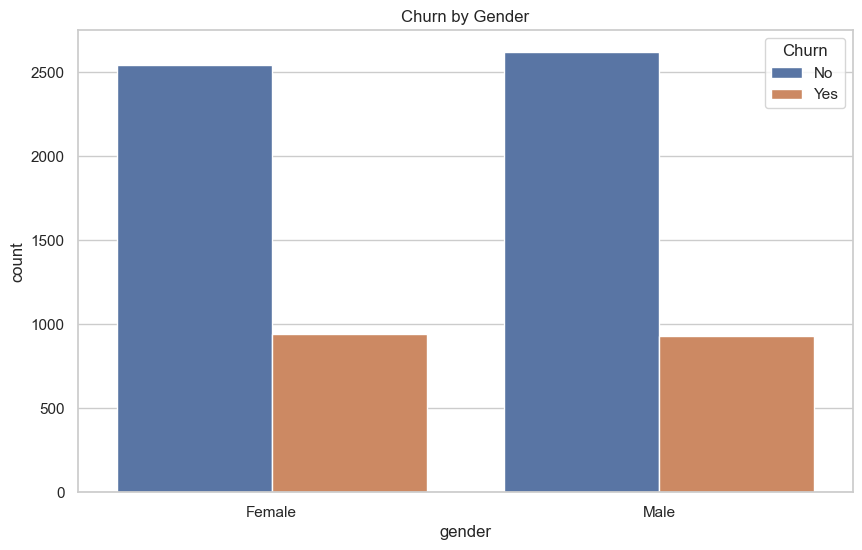

In [10]:
sns.countplot(data=df, x="gender", hue="Churn")
plt.title("Churn by Gender")
plt.show()

This shows whether churn differs between male and female customers.

## Churn by Contract Type

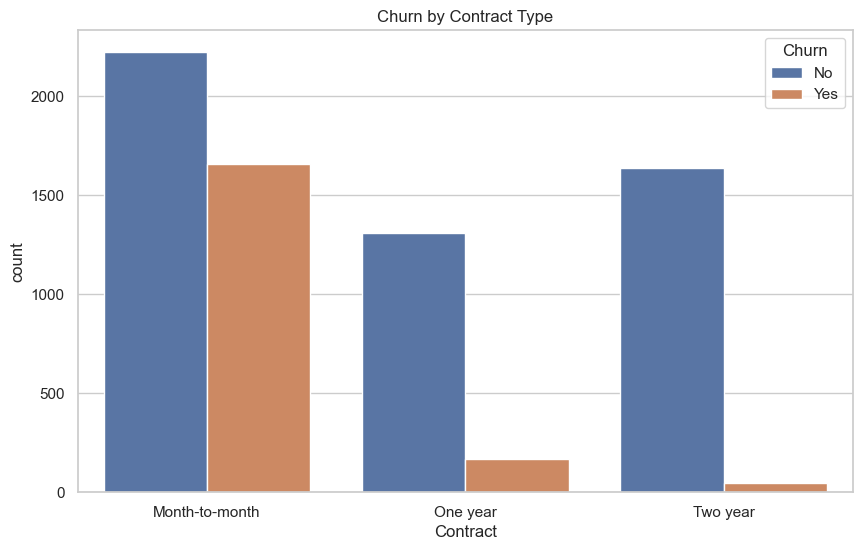

In [11]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.show()

We explore whether contract type influences churn behavior.

## Churn by Internet Service

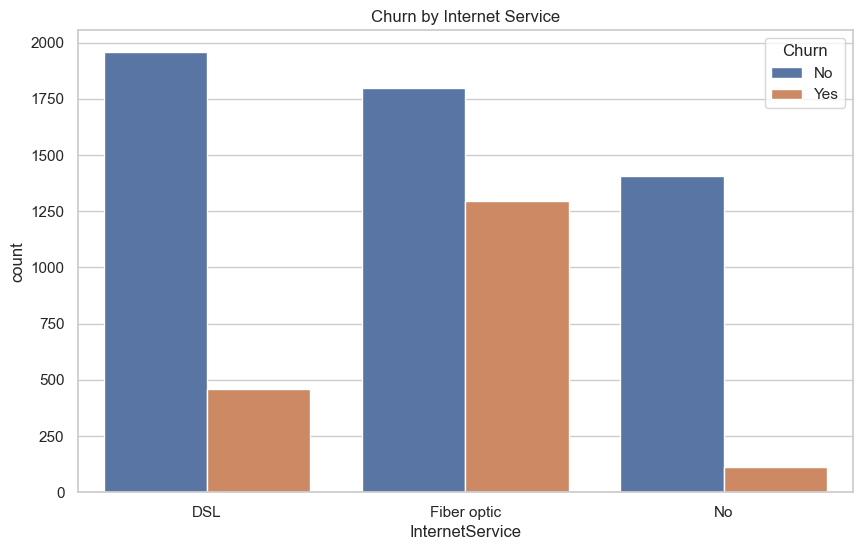

In [12]:
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.show()

This helps identify whether certain service types are associated with higher churn.

## Churn by Payment Method

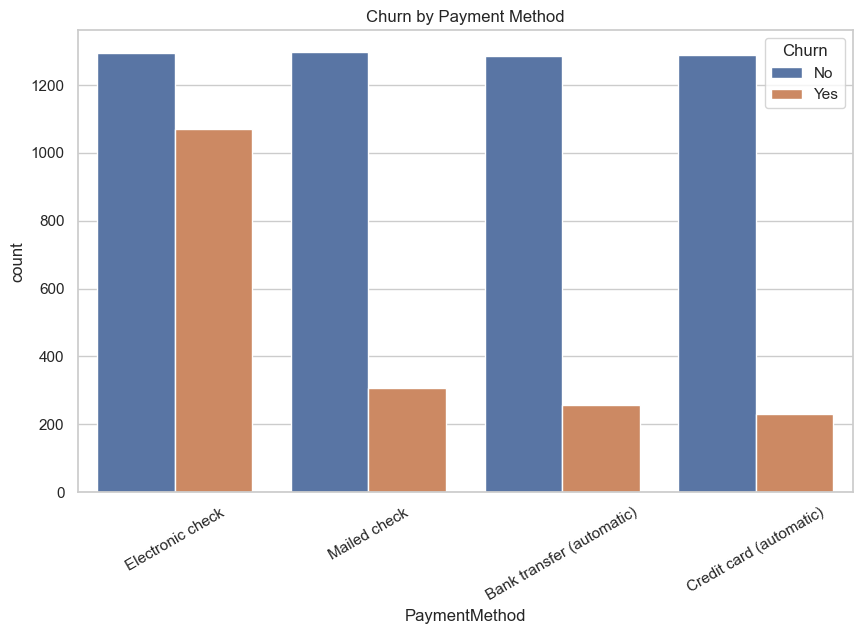

In [13]:
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.xticks(rotation=30)
plt.title("Churn by Payment Method")
plt.show()

We analyze whether payment behavior is linked to churn.

## Churn by Senior Citizen

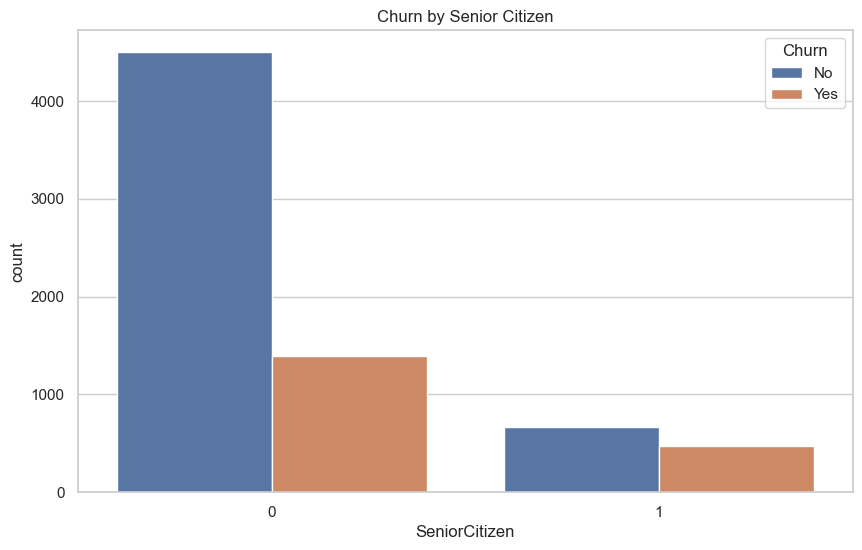

In [14]:
sns.countplot(data=df, x="SeniorCitizen", hue="Churn")
plt.title("Churn by Senior Citizen")
plt.show()

We compare churn behavior across age-related segments.

## Correlation Analysis

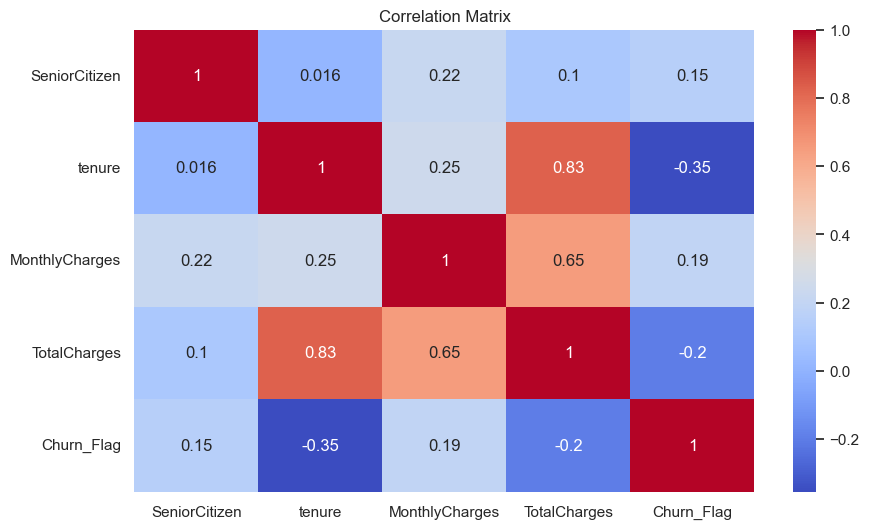

In [15]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

The correlation matrix helps identify relationships between numeric variables.

For example, TotalCharges is typically strongly correlated with tenure.

## Monthly Charges vs Churn

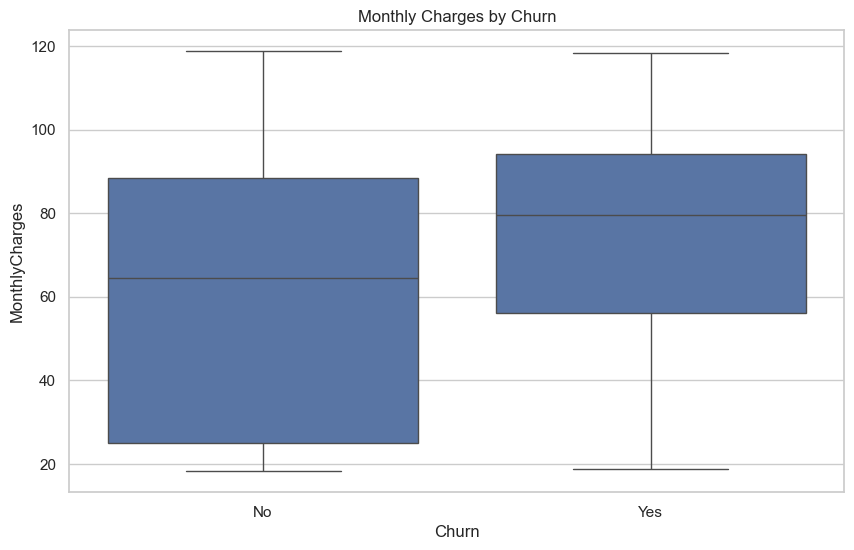

In [16]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.show()

This shows whether churned customers tend to have higher or lower monthly charges.

## Tenure vs Churn

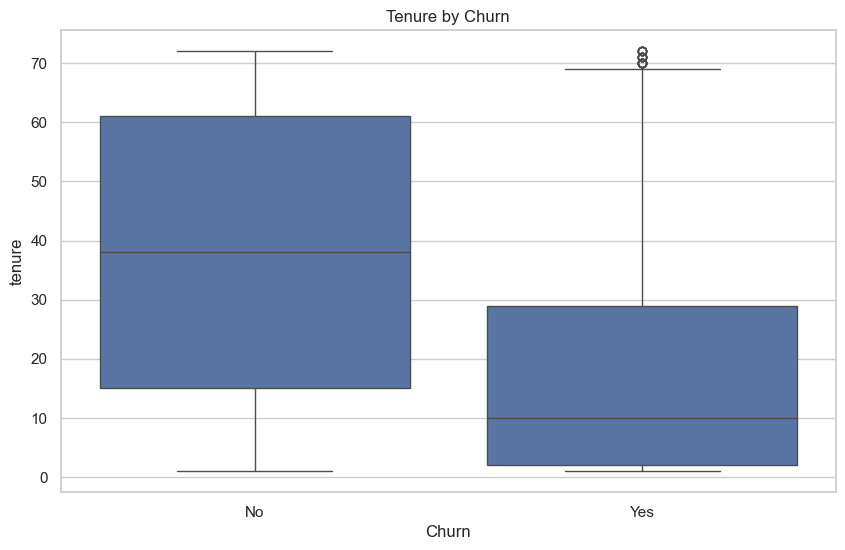

In [17]:
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure by Churn")
plt.show()

This helps identify whether churn is concentrated among newer customers.

## Key Observations

From the exploratory analysis, we observe:

- churn is present in a significant portion of customers
- early-tenure customers appear more likely to churn
- certain contract types show different churn patterns
- higher monthly charges may be associated with higher churn
- some services and payment methods show distinct behavior patterns

These insights will guide the business and financial analysis in the next steps.

## Conclusion

The dataset shows clear patterns in customer behavior and churn.

Exploratory analysis provides a foundation for deeper business insights and helps identify key variables that influence customer retention.

The next step is to perform a detailed business analysis to quantify and interpret these patterns.